# 데이터 처리

결측치 (Missing Value)
====================
- 정의: 데이터에서 값이 존재하지 않는 부분 (NaN, None, NaT 등)
- 왜 문제인가: 대부분의 통계/머신러닝 알고리즘은 결측치가 있으면
  계산이 불가능하거나 에러가 남

- 처리 방법
  1. 삭제 (Deletion)
     - 행 삭제: 결측치가 있는 행 자체를 제거
     - 열 삭제: 결측 비율이 너무 높은 컬럼을 통째로 제거
     - 단점: 데이터 손실, 결측 자체가 패턴이면 편향 발생 가능

  2. 대체 (Imputation)
     - 평균(mean)으로 채움: 단순하지만 이상치에 민감
     - 중앙값(median)으로 채움: 이상치가 있을 때 더 안전
     - 최빈값(mode)으로 채움: 범주형 데이터에 사용
     - 그룹별 통계값으로 채움: 더 정교한 방식 (예: 성별/등급별 평균)

  3. 예측 기반 대체
     - 다른 컬럼들과의 관계를 이용해 결측치를 예측해서 채움 (회귀, KNN 등)

  4. 결측 자체를 정보로 활용
     - "결측 여부"를 새로운 컬럼(플래그)으로 만들어 활용


이상치 (Outlier)
====================
- 정의: 다른 데이터들과 동떨어진, 극단적으로 크거나 작은 값
- 왜 문제인가: 평균 같은 통계량을 왜곡시키고, 회귀 모델처럼
  이상치에 민감한 모델의 성능을 크게 흔들 수 있음
  (단, 이상 탐지 문제에서는 이상치 자체가 찾아야 할 답이 되기도 함)

- 탐지 방법
  1. IQR (사분위수 범위, Interquartile Range)
     - 데이터를 4등분했을 때 Q1(25%)과 Q3(75%) 사이 범위
     - IQR = Q3 - Q1
     - Q1 - 1.5×IQR 보다 작거나 Q3 + 1.5×IQR 보다 크면 이상치로 판단
     - 더 엄격하게 볼 땐 1.5 대신 3을 곱해 "극단치" 기준으로 사용
     - 박스플롯(상자수염그림)으로 시각화해서 확인 가능
    

- 처리 방법
  1. 제거: 이상치 행을 데이터셋에서 삭제
  2. 대체: 경계값이나 평균/중앙값으로 눌러서 바꿈 (Capping/Winsorizing)
  3. 변환: 로그 변환 등으로 분포를 완화시켜 이상치 영향 축소
  4. 유지: 이상치가 오류가 아니라 의미 있는 극단값이면 그대로 둠

데이터 불균형 (Class Imbalance) 처리 방법
====================================

- 정의: 분류 문제에서 클래스(범주)별 데이터 개수 차이가 심한 상태
  (예: 정상 거래 99% vs 사기 거래 1%)
- 왜 문제인가: 모델이 다수 클래스 위주로 학습되어, 소수 클래스를
  거의 예측하지 못하는 과적합이 발생함 (정확도는 높아 보여도 실제로는 편향된 모델)


1. 오버샘플링 (Over-sampling)
   - 소수 클래스의 데이터 개수를 늘려서 균형을 맞추는 방법
   - 랜덤 오버샘플링: 소수 클래스 데이터를 단순 복제해서 늘림
     -> 구현이 쉽지만, 같은 데이터를 반복 학습해 과적합 위험이 있음
   - SMOTE: 소수 클래스 데이터들 사이를 보간(interpolation)하여
     "새로운 합성 데이터"를 생성
     -> 단순 복제보다 정교하며, 실무에서 가장 널리 쓰이는 방법
   - 주의: 오버샘플링은 반드시 train 데이터에만 적용 (valid/test에 적용하면
     검증 결과가 왜곡됨)


2. 언더샘플링 (Under-sampling)
   - 다수 클래스의 데이터 개수를 줄여서 균형을 맞추는 방법
   - 랜덤 언더샘플링: 다수 클래스 데이터를 무작위로 제거
     -> 구현이 쉽지만, 유용한 정보가 담긴 데이터까지 손실될 위험이 있음
   - Tomek Links: 서로 다른 클래스이면서 가장 가까운 데이터 쌍을 찾아,
     그중 다수 클래스 데이터를 제거해 클래스 경계를 명확하게 정리
     -> 단독보다는 SMOTE와 결합(SMOTE+Tomek)해서 보조적으로 많이 사용


3. 알고리즘 레벨 조정 (Algorithm-level Approach)
   - 데이터 자체를 건드리지 않고, 모델 학습 방식을 조정하는 방법
   - class_weight 조정: 소수 클래스를 틀렸을 때 더 큰 페널티(가중치)를
     부여하여, 모델이 소수 클래스에도 신경 쓰도록 유도
   - 평가지표 변경: Accuracy 대신 F1-score, Precision/Recall,
     Confusion Matrix 등을 사용해 소수 클래스 성능을 제대로 확인
     (Accuracy는 불균형 데이터에서 성능을 왜곡해서 보여줄 수 있음)

# 의사결정나무 (Decision Tree)
- 정의: 조건(질문)을 통해 데이터를 계속 나누며 정답을 찾아가는 모델 (스무고개 방식)
- 용도: 회귀, 분류 둘 다 가능
- 특징: 과적합에 취약함 → 단독보다 여러 개를 모은 RandomForest 등으로 실무에서 더 많이 사용
- 중요 개념: feature_importances_ (특성중요도)
  - 어떤 변수가 예측에 가장 큰 영향을 미쳤는지 확인 가능
  - 모델 "해석/설명"에 핵심적으로 쓰임 (성능 자체를 높이진 않음)

# 특성 엔지니어링 (Feature Engineering)
정의: 새로운 관측치(행) 없이, 기존 데이터를 가공/변형해서
      모델이 더 잘 학습할 수 있는 특징(feature)을 만들어내는 작업

## 주요 기법

1. 스케일링 (Scaling)
   - 숫자 변수들의 범위를 통일시킴 (MinMaxScaler, StandardScaler 등)
   - 필요 여부: 트리 계열(RandomForest 등)은 불필요, 거리/기울기 기반 모델(KNN, 로지스틱회귀)과
     딥러닝은 필요

2. 인코딩 (Encoding) - 범주형 데이터를 숫자로 변환
   - Label Encoding(map 등): 범주가 2개거나 순서가 있는 경우
   - 더미/원-핫 인코딩(get_dummies): 범주가 3개 이상이고 순서·크기 의미가 없는 경우
     (잘못 쓰면 모델이 없는 크기/순서 관계를 착각해서 학습함)

3. 비닝 (Binning)
   - 연속형 숫자를 구간(범주)으로 나눔 (예: 나이 → 어린이/청년/중년/노년)
   - 이상치·노이즈 완화, 비선형 패턴 포착에 도움
   - 트리 계열 모델엔 효과 제한적, 선형 모델엔 유의미한 경우 많음

4. 정보 추출 (Extraction)
   - 원본 컬럼(텍스트 등) 안에 숨어있는 유용한 정보를 뽑아 새 변수로 생성
   - 예: 이름(Name)에서 호칭(Title) 추출 → 나이대/성별/신분 정보 압축

## 핵심 판단 포인트
- 어떤 기법을 쓸지는 "모델 종류"와 "변수의 성격(순서 유무, 범주 개수 등)"에 따라 달라짐
  → 정해진 정답이 없고, 판단력이 필요한 영역

# numpy

In [24]:
# numpy: 다차원 배열 처리를 위한 패키지
import numpy as np

# 정수 numpy 배열
a = np.array([1, 2, 3, 4])

# 소수 numpy 배열
b = np.array([1, 2, 3, 4], dtype=float)
print(a, b)

# 9까지
c = np.arange(10)
# 1부터 3까지
d = np.arange(1, 4)
# 1부터 8까지 2의 간격으로
e = np.arange(1, 8, 2)
print(c, d, e)

# 0으로 채워진 5길이의 배열
f = np.zeros(5)
g = np.zeros(5, dtype=int)
print(f, g)

# 1으로 채워진 5길이의 배열
h = np.ones(5)
i = np.ones(5, dtype=int)
print(h, i)

# 0에서 1사이의 소수점으로 채워진 5길이의 배열
j = np.random.rand(5)
# 0에서 1사이의 소수점으로 채워진 5길이의 배열
k = np.random.rand(2, 3)
print(j, k)

# 1, 10까지의 정수 난수를 5길이로 생성
l = np.random.randint(1, 10, size=5)
print(l)

# shape: 배열의 생김새
print(k.shape)
# size: 배열 원소의 개수
print(k.size)

print(k[0, 2])

# 사이즈는 같지만 배열의 형태가 바뀜
# 차원을 곱했을 때 기존의 size와 같으면 됨(2, 1, 2도 가능)
a = a.reshape((2, 2))

print(a)

# 배열 자르기
# 0번째 축 전체에서 0번째 요소들만 들고 와 배열 형성
k1 = k[:, 0]
# 0번째 축 마지막요소에서 전체를 가져와 배열 형성
k2 = k[-1, :]
k3 = k[-1, 0]
print(k1)
print(k2)
print(k3)

# concat으로 합치기
m = np.array([[1, 2, 3], [4, 5, 6]])
n = np.array([[7, 8, 9], [10, 11, 12]])
# 0번째 축 방향으로 합치기
print(np.concatenate((m, n), axis=0))
# 백터 연산 가능
print(m + n)
print(m - n)

[1 2 3 4] [1. 2. 3. 4.]
[0 1 2 3 4 5 6 7 8 9] [1 2 3] [1 3 5 7]
[0. 0. 0. 0. 0.] [0 0 0 0 0]
[1. 1. 1. 1. 1.] [1 1 1 1 1]
[0.33941155 0.00902991 0.28223269 0.96884302 0.25661508] [[0.2293411  0.46784679 0.99018297]
 [0.48617429 0.18802965 0.5807934 ]]
[4 2 3 4 2]
(2, 3)
6
0.9901829701680397
[[1 2]
 [3 4]]
[0.2293411  0.48617429]
[0.48617429 0.18802965 0.5807934 ]
0.48617428569677723
[[ 1  2  3]
 [ 4  5  6]
 [ 7  8  9]
 [10 11 12]]
[[ 8 10 12]
 [14 16 18]]
[[-6 -6 -6]
 [-6 -6 -6]]


# pandas

In [33]:
import pandas as pd
# Series: 1차원 배열의 자료구조이며 각 값에 연결된 index도 저장
# series 형성 기본 문법
obj = pd.Series([4, 7, -5])
print(obj)
# index에 이름 붙이기
stock0 = pd.Series([10, 20, 30], index=['naver', 'skt', 'LG'])
stock1 = pd.Series([30, 10, 20], index=['skt', 'LG', 'naver'])
# index가 같으면 같은 index끼리 덧셈을 수행
merge = stock0 + stock1
print(merge)

# DataFrame: 여러 개의 Series가 모여서 열과 행을 이룬 데이터
# 딕셔너리를 사용하여 DataFrame 생성
raw_data = {
  'col0': [1, 2, 3, 4],
  'col1': [10, 20, 30, 40],
  'col2': [100, 200, 300, 400],
}
data = pd.DataFrame(raw_data)
print(data)
# index와 column을 지정해준다.(column명은 딕셔너리의 key와 같아야 데이터가 정상 삽입된다.)
data2 = pd.DataFrame(raw_data, index=[1, 3, 5, 2], columns=['col1', 'col0', 'col2'])
print(data2)

# 딕셔너리 대신 2차원 배열 사용 가능
a = [[1, 2], [3, 4]]
df = pd.DataFrame(a, index=[0, 1], columns=['a', 'b'])
print(df)

# df.loc: idx에 해당하는 값을 추출
print(data2.loc[1:3, ['col1', 'col2']])

# df.iloc: 정수기반 인덱스를 참조하는 인덱싱
print(data2.iloc[0:2, [2,1]])

data3 = pd.DataFrame({'A': [3, 2, 1], 'B': [4, 5, 6]}, index=['a', 'b', 'c'])
# df.sort_value(): 정렬
print(data3.sort_values(by='A'))
# df.drop(): 행 또는 열 삭제
print(data3.drop(labels='a'))

0    4
1    7
2   -5
dtype: int64
LG       40
naver    30
skt      50
dtype: int64
   col0  col1  col2
0     1    10   100
1     2    20   200
2     3    30   300
3     4    40   400
   col1  col0  col2
1    10     1   100
3    20     2   200
5    30     3   300
2    40     4   400
   a  b
0  1  2
1  3  4
   col1  col2
1    10   100
3    20   200
   col2  col0
1   100     1
3   200     2
   A  B
c  1  6
b  2  5
a  3  4
   A  B
b  2  5
c  1  6


# matplotlib

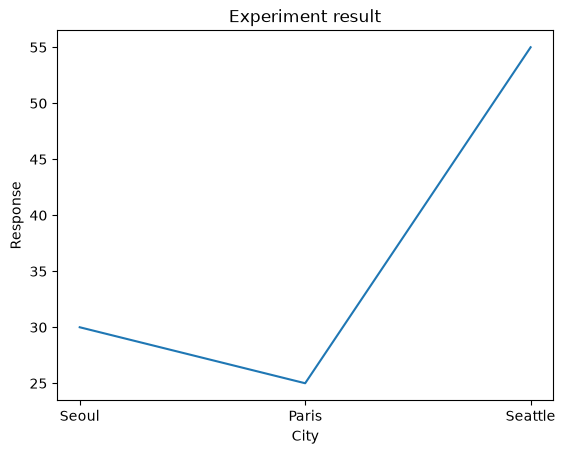

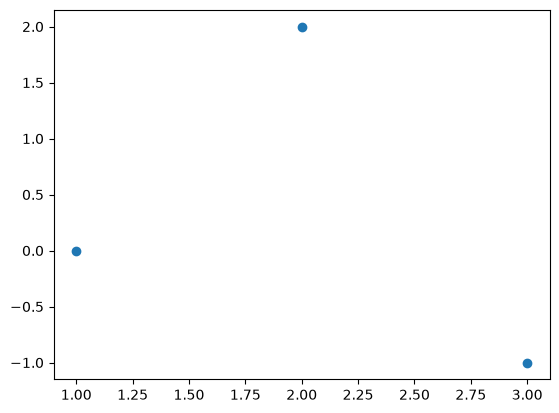

In [2]:
import matplotlib.pyplot as plt
plt.plot(['Seoul', 'Paris', 'Seattle'], [30, 25, 55])
plt.xlabel('City')
plt.ylabel('Response')
plt.title('Experiment result')
plt.show()

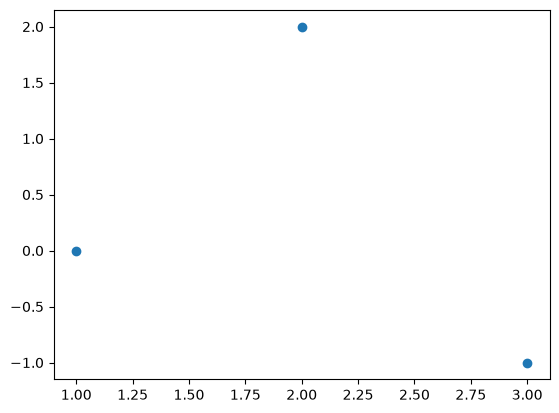

In [ ]:
# scatter
plt.scatter([1, 3, 2], [0, -1, 2])
plt.show()

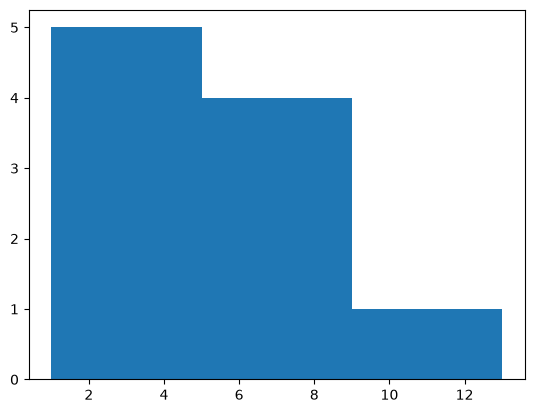

In [ ]:
# histogram
# bin: 들어간 데이터들의 구간을 나누어서 그 데이터의 개수가 몇 개인지 표시해준다.
# 예) 해당 구간을 3개로 나누면 1 ~ 13까지 있으므로 [1, 5), [5, 9), [9, 13]까지 나누어 그 안에 들어간 개수를 막대로 그린다.
plt.hist([1, 5, 6, 4, 7, 13, 3, 6, 2, 2], bins=3)
plt.show()

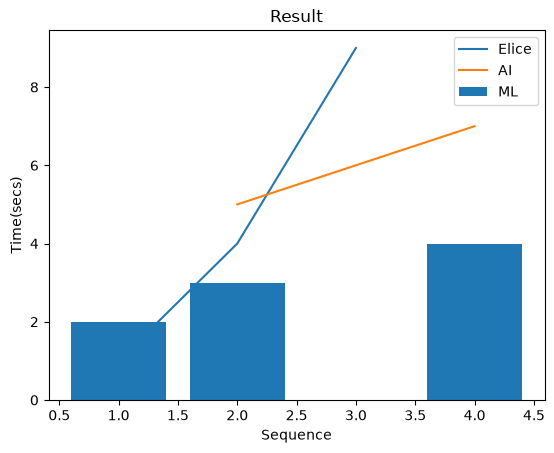

In [ ]:
# 여러 개 그래프 동시에 출력
plt.plot([1, 2, 3], [1, 4, 9])
plt.plot([2, 3, 4], [5, 6, 7])
plt.bar([1, 2, 4], [2, 3, 4])
plt.xlabel('Sequence')
plt.ylabel('Time(secs)')
plt.title('Result')
plt.legend(['Elice', 'AI', 'ML'])
plt.show()

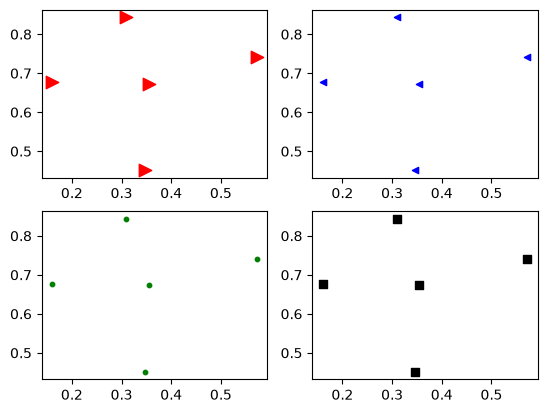

In [40]:

x = np.random.rand(5)
y = np.random.rand(5)

# 221: 2행 2열의 첫 번째 그래프
plt.subplot(221)
plt.scatter(x, y, s=80, c='r', marker='>')
plt.subplot(222)
plt.scatter(x, y, s=20, c='b', marker='<')
plt.subplot(223)
plt.scatter(x, y, s=10, c='g', marker='o')
plt.subplot(224)
plt.scatter(x, y, s=30, c='k', marker='s')

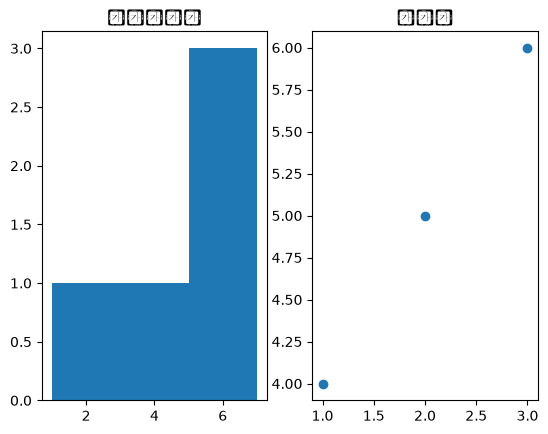

In [39]:
# plt.subplots(): 여러 개의 그래프를 담을 수 있는 "그림판(figure)"과 그 안의 "칸(axes)들"을 한 번에 만들어주는 함수
fig, axes = plt.subplots(1, 2)

axes[0].hist([1, 5, 6, 4, 7], bins=3)
axes[0].set_title('히스토그램')

axes[1].scatter([1, 2, 3], [4, 5, 6])
axes[1].set_title('산점도')

plt.show()


# 벡터

- 스칼라 (Scalar): 숫자 하나. 크기만 있고 방향은 없음 (예: 온도 25.3, 속도의 크기 60)
- 벡터 (Vector): 숫자들이 순서대로 나열된 것. 크기와 방향을 동시에 가짐 (예: 센서값 여러 개를 한 줄로 나열한 것, 혹은 "북쪽으로 60km/h"처럼 방향이 있는 값)
- 행렬 (Matrix): 벡터(행)들이 여러 개 쌓인 표. 여러 시점 또는 여러 항목의 벡터를 한 번에 묶어서 표현한 것 (예: 여러 시점의 센서 데이터 전체를 표로 쌓은 것)
- 내적 (Dot product): 두 벡터의 각 성분을 곱해서 다 더한 값 (결과는 숫자 하나). 동시에 두 벡터가 얼마나 비슷한 방향인지를 나타내는 숫자이기도 함 (같은 방향일수록 크고, 직각이면 0, 반대 방향이면 음수)
- 선형결합: 벡터들에 각각 스칼라를 곱하여 더한 것
- 선형독립: 주어진 벡터들이 서로 독립적(벡터들의 선형 결합이 0일 때 모든 스칼라가 0인 경우)

# 행렬

- 행렬 덧셈/뺄셈 (Matrix Addition/Subtraction): 같은 위치의 성분끼리 더하거나 빼는 연산. 두 행렬의 shape가 완전히 같아야 함 (예: 정규화에서 평균 빼기, 시계열 차분, 예측값과 실제값의 오차 계산)
- 행렬곱 (Matrix Multiplication): 앞 행렬의 행과 뒤 행렬의 열을 각각 내적해서 계산. (m×n) 행렬과 (n×p) 행렬처럼 안쪽 숫자가 같아야 곱셈이 가능하며, 결과는 (m×p) 행렬이 됨 (예: 선형회귀·신경망에서 입력 데이터와 가중치를 곱해 예측값을 구하는 연산)
- 전치행렬 (Transpose): 행과 열을 서로 바꾸는 것 (`A.T`). shape가 안 맞을 때 맞춰주는 역할을 하며, 행렬곱 계산에서 자주 등장함